# Disneyland Reviews — Natural-Language Q&A Endpoint

Task 2 of the assignment: let the customer-experience team ask open-ended questions like *"What do visitors from Australia say about Disneyland in HongKong?"* or *"Is the staff in Paris friendly?"*, answered using **both** the review text and metadata.

## How it works

A single open-text question is hard to answer well with either pure metadata filtering (loses the nuance in review text) or pure semantic search (can't reliably count/average — "is it crowded in June" needs real statistics, not just a few similar-sounding snippets). So the pipeline combines both:

1. **Filter extraction** — an LLM call turns the question into a structured filter (branch, country, year/month/season, rating range, relevant aspect tags) plus a cleaned-up semantic search phrase.
2. **Exact aggregates** — that filter is applied directly to the full enriched DataFrame (pandas), giving real counts, average ratings, and per-aspect sentiment breakdowns for the matching subset — never guessed by the LLM.
3. **Grounded snippets** — the same filter becomes a Chroma metadata `where=` clause, narrowing semantic search to representative quotes from *within* that matching subset.
4. **Relaxation** — if too few reviews match (under 5), filter conditions are dropped one at a time (month → rating → aspects → season → year → country, branch last) until there's enough data, and this is reported transparently in the answer.
5. **Grounded generation** — a final LLM call answers using *only* the computed aggregates and retrieved snippets, citing `Review_ID`s and stating the sample size.

We deliberately built filter-extraction manually rather than using LangChain's `SelfQueryRetriever`: it's been moved to the legacy `langchain_classic` package in the current LangChain version, and — more importantly — we need the *same* parsed filter to drive both the pandas aggregate query and the Chroma vector filter, which an off-the-shelf retriever doesn't expose a hook for.

Embeddings are local (`BAAI/bge-m3`, run on the Mac's GPU) rather than an API, and chat calls run on Groq (`openai/gpt-oss-20b`) rather than OpenAI directly — both LLM-enrichment and Q&A chat calls hit OpenAI's real-time daily request cap partway through this build, so we moved to a provider with a larger quota to keep things fast.

In [1]:
import sys
sys.path.insert(0, '../src')

import cleaning
import enrichment
import vectorstore
import rag_pipeline
import eval as eval_mod
from config import ENRICHMENT_CHECKPOINT_PATH, CHROMA_PERSIST_DIR, RAW_CSV_PATH

df, _ = cleaning.clean(RAW_CSV_PATH)
edf = enrichment.load_enriched(df, ENRICHMENT_CHECKPOINT_PATH)
print(f"{edf['overall_sentiment'].notna().sum()} / {len(edf)} rows enriched")

/Users/mhdaldahmani/venvs/ai-interview/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


42622 / 42636 rows enriched


In [2]:
docs = vectorstore.build_documents(edf)
store = vectorstore.build_or_load_vectorstore(docs, CHROMA_PERSIST_DIR)
print('vector store size:', store._collection.count())

pipeline = rag_pipeline.RagPipeline(edf, store)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 62942.73it/s]

42636 already indexed, 0 to add
vector store size: 42636


## Worked example

One of the assignment's sample questions, showing the answer plus the full trace (extracted filter, computed aggregates, retrieved snippets) for transparency.

In [3]:
trace = pipeline.ask('Is the staff in Paris friendly?', return_trace=True)

print('Extracted filter:', trace['filter'])
print('Relaxation log:', trace['relaxation_log'])
print('Country note:', trace['country_note'])
print('Sample size:', trace['aggregates'].get('count'))
print()
print('ANSWER:')
print(trace['answer'])

Extracted filter: branch='Disneyland_Paris' country=None year=None month=None season=None rating_min=None rating_max=None aspects=['staff_service'] semantic_query='staff and cast member friendliness'
Relaxation log: []
Country note: None
Sample size: 4777

ANSWER:
**Answer**

Based on the 4,777 reviews that mention staff service in Disneyland Paris:

- **Positive mentions:** 2,296  
- **Negative mentions:** 2,159  
- **Mixed mentions:** 276  
- **Neutral mentions:** 46  

The sentiment is roughly balanced, with a slight edge toward positive but a substantial number of negative comments. Therefore, the staff are generally perceived as friendly, but many visitors also report less pleasant experiences.

**Supporting snippets**

- Positive:  
  - “All cast members were very friendly and helpful.” (Review_ID 512242269)  
  - “Great cast members always happy.” (Review_ID 273950746)  
  - “Everyone at the park (cast members) were soooo nice and spoke English!!!” (Review_ID 590759883)

- Negat

## Evaluation

A golden set of 25 questions (the 4 from the assignment + 21 harder multi-constraint ones). Each question is scored on **3 dimensions**:

| Metric | How it's measured | What it catches |
|---|---|---|
| **Filter accuracy** | Exact field-match vs. a hand-written expected filter | Wrong park / country / time period |
| **Faithfulness** (1–5, LLM judge) | Is every claim in the answer traceable to the computed aggregates + retrieved snippets? Rubric has 5 gradations, not just yes/no | Hallucinated numbers or quotes |
| **Answer quality** (1–5, LLM judge) | Is the answer direct (clear verdict), specific (hard numbers), and honest (states sample size and limitations)? | Vague or over-hedged answers |
| **Count correct** | Does the answer state the right sample size? (programmatic — no LLM call) | Numeric hallucination on the most checkable fact |

In [4]:
results = eval_mod.run_eval(pipeline)

display_cols = ['question', 'sample_size', 'filter_accuracy', 'faithfulness', 'answer_quality', 'count_in_answer']

def shade_bool(val):
    if val is True:  return 'color: #2e7d32; font-weight: bold'
    if val is False: return 'color: #c62828; font-weight: bold'
    return ''

(results[display_cols]
 .style
 .background_gradient(cmap='RdYlGn', subset=['faithfulness', 'answer_quality'], vmin=1, vmax=5)
 .background_gradient(cmap='RdYlGn', subset=['filter_accuracy'], vmin=0, vmax=1)
 .map(shade_bool, subset=['count_in_answer'])
 .format({'filter_accuracy': '{:.0%}', 'sample_size': '{:,}'})
)

,question,sample_size,filter_accuracy,faithfulness,answer_quality,count_in_answer
0,What do visitors from Australia say about Disneyland in HongKong?,"1,634",100%,5,5,False
1,Is spring a good time to visit Disneyland?,"6,196",100%,5,5,True
2,Is Disneyland California usually crowded in June?,637,100%,5,5,True
3,Is the staff in Paris friendly?,"4,777",100%,5,5,True
4,I hate waiting in queues. What is the best time of year to visit Disneyland Hong Kong?,"3,992",100%,2,5,True
5,How do reviewers from the United States rate Disneyland Paris?,"1,330",100%,5,4,True
6,What do people complain about most at Disneyland California?,"19,400",100%,2,5,True
7,Are the rides at Hong Kong Disneyland worth it?,"7,549",100%,2,5,True
8,Is food expensive at Disneyland Paris?,"6,542",100%,3,4,True
9,How was Disneyland California rated by visitors in December?,"1,672",100%,2,5,True


=== Summary ===
Filter accuracy:  100%
Faithfulness:     3.80 / 5
Answer quality:   4.64 / 5
Count correct:    21 / 25 (84%)


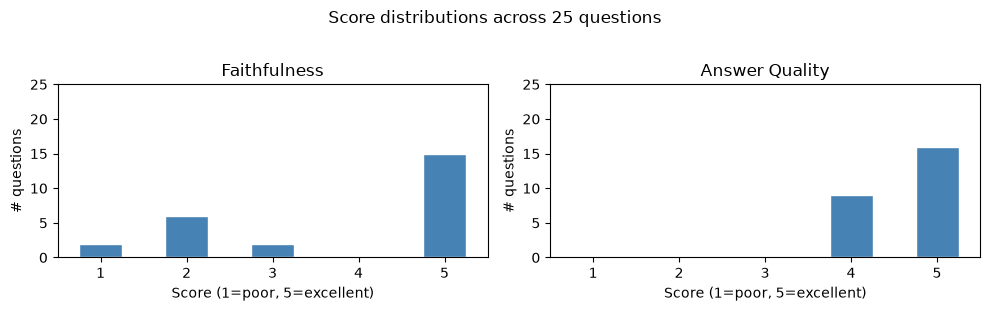

In [5]:
import matplotlib.pyplot as plt

print('=== Summary ===')
print(f'Filter accuracy:  {results["filter_accuracy"].mean():.0%}')
print(f'Faithfulness:     {results["faithfulness"].mean():.2f} / 5')
print(f'Answer quality:   {results["answer_quality"].mean():.2f} / 5')
print(f'Count correct:    {results["count_in_answer"].sum()} / {results["count_in_answer"].notna().sum()} ({results["count_in_answer"].mean():.0%})')

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, col in zip(axes, ['faithfulness', 'answer_quality']):
    counts = results[col].value_counts().sort_index().reindex(range(1, 6), fill_value=0)
    counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Score (1=poor, 5=excellent)')
    ax.set_ylabel('# questions')
    ax.set_ylim(0, 25)
    ax.tick_params(axis='x', rotation=0)
plt.suptitle('Score distributions across 25 questions', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
print('=== Lowest-scoring answers (faithfulness) ===')
worst = results.nsmallest(3, 'faithfulness')
for _, row in worst.iterrows():
    print(f'Q: {row["question"]}')
    print(f'   faithfulness={row["faithfulness"]}  answer_quality={row["answer_quality"]}  count_correct={row["count_in_answer"]}')
    print(f'   Why: {row["faithfulness_reason"]}')
    print()

=== Lowest-scoring answers (faithfulness) ===
Q: What do visitors from Canada say about ticket prices at Disneyland California?
   faithfulness=1  answer_quality=4  count_correct=False
   Why: The answer invents details about the reviews (e.g., 5‑day pass deal) that are not present in the provided snippets, and incorrectly claims the reviewers are from Canada. It also misstates content about weather. Thus it contains key invented facts and contradicts the evidence.

Q: What do reviewers from the Philippines say about Hong Kong Disneyland's food?
   faithfulness=1  answer_quality=5  count_correct=False
   Why: The answer incorrectly claims that the Filipino reviewer mentioned food being expensive and a bottle of water costing HK$20, but the provided snippet does not contain any such detail. This is an invented claim that contradicts the evidence. The rest of the answer is accurate about the single review, but the invented detail lowers the score to 1.

Q: I hate waiting in queues. What 

## Try your own question

Edit the question below and re-run the cell.

In [7]:
question = "I hate waiting in queues. What is the best time of year to visit Disneyland Hong Kong?"

print(pipeline.ask(question))

**Answer**

Based on the 3,992 reviews that mention queues at Disneyland Hong Kong, the overall sentiment toward queue‑times is mixed: 1,943 reviews are positive, 1,603 are negative, 259 are mixed, and 187 are neutral.  The data set does not include a time‑of‑year breakdown, so we cannot compute a precise “best month” from the aggregate statistics alone.  

However, the representative snippets give us some clues about when queues tend to be shorter:

| Snippet | Key point about queue length | Review ID |
|---------|------------------------------|-----------|
| “Avoid weekends, or local (Chinese) school holidays… we were there on a Saturday, and it was tremendously crowded.” | Weekends and school holidays → long queues | 138610905 |
| “Visiting the park in Dec is cool… I think it’s the best time to visit but not during holiday or weekend.” | December (outside holidays) → shorter queues | 332867662 |
| “I visited in Dec 2010… it’s the month of school holidays so the place is jam packed… 